<center><h1 style="font-size: 50px; font-weight: bold;">Random Walks in $R^2$</h1></center>
<center><h1 style="font-size: 30px; font-weight: bold;">Project for Python in Data Science</h1></center>
<h2 style="font-size: 24px; font-weight: bold; margin-top: 30px;">
    Authors:
</h2>

* **Kacper Bryda**
* **Rafał Kiełbasa**
* **Sebastian Bąk**

### Aim of the project
We want to analyse behaviour of random walks in second dimension using simulation of different distributions.
Our project mainly consists of three parts, such as:
* theoretical background,
* simulations of random walks,
* interpretation after visualisation.

<h2>Part 1: Theoretical background</h2>


A random walk in $\mathbb{R}^2$ is defined as:
$$
    S_0 = x_0 \in \mathbb{R}^2, \quad S_n = x_0 + \sum_{k=1}^{n} X_k,
$$
where $(X_k)$ are i.i.d. random variables in $\mathbb{R}^2$. The process $(S_n)$ is a $\textbf{Markov chain with a continuous state space}$. We set $S_0=(0,0)$. Our goal is to study reccurence of random walks, which means that we want to know if the process will return infinitely often to any arbitrary small neighbourhood of the starting point $S_0$.

We are going to simulate random walks in $\mathbb{R}^2$ with different increment distributions. We will check the effect of increment distributions on return behaviour and plot the outcomes. Let
$$
    S_{n+1} = S_n + X_{n+1},
$$
where $X_n = (X_n^{(1)}, X_n^{(2)})$, and $X_n^{(1)}, X_n^{(2)}$ are i.i.d.
1. Gaussian increments: $X_n \sim N(0, \sigma^2 I_2)$,
2. Uniform increments: $X_n^{(i)} \sim U(-a, a)$,
3. Heavy-tailed increments: Cauchy


As a brief reminder, the $\textbf{Cauchy distribution}$ is a continuous probability distribution known for its heavy tails. The standard Cauchy distribution, denoted as $\text{Cauchy}(0,1)$, is equivalent to the $t$-Student distribution with 1 degree of freedom ($\nu = 1$).

Unlike the Gaussian distribution, the Cauchy distribution has undefined mean and variance. The probability density function (PDF) of the general Cauchy distribution is defined by two parameters: the location parameter $x_0$ (specifying the peak's location) and the scale parameter $\gamma$ (specifying the width at half-maximum).

The PDF is given by the formula:
$$
    f(x) = \frac{1}{\pi\gamma \left[1 + \left(\frac{x - x_0}{\gamma}\right)^2\right]}, \quad x\in\mathbb{R}
$$
where $\gamma > 0$.

<h2>Part 2: Simulations with plots</h2

#### Function for simulations

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def simulation(n_steps, epsilon, dist_type='gaussian'):
    if dist_type == 'gaussian':
        steps = np.random.randn(n_steps, 2)
        #For normal distribution
    elif dist_type == 'Uniform':
        steps = np.random.uniform(-1, 1, size=(n_steps, 2))
        #For uniform distribution
    elif dist_type == 'Cauchy':
        steps = np.random.standard_cauchy(size=(n_steps, 2))
        #For Cauchy distribution
    else:
        raise ValueError("Unknown distribution type")

    # vector of walk, we combine starting point, and cumulative sums of realizations of random variables.
    path =np.vstack(([0, 0], np.cumsum(steps, axis=0)))

    #distances, checking if our point from random walk is closer than epsilon to the starting point
    distances= np.linalg.norm(path[1:], axis=1)

    Beta_epsilon = np.where(distances <= epsilon)[0]

    Tau_epsilon = None
    if len(Beta_epsilon) > 0:
        Tau_epsilon = Beta_epsilon[0] +1
    return path, Tau_epsilon

* ### Simulation Parameters

In [12]:
#Number of steps
N = 100000
#Size of Beta_epsilon circle
epsilons = [0.1,0.5,1.0]
#Number of repetitions, for calculating probabilities
reps = 500

* ### Normal distribution

In [13]:
all_stats = {}
for epsilon in epsilons:
    print("_" * 60)
    print(f"*** Simulation start (N={N}, Epsilon={epsilon}) ***")
    return_times = []
    returns_count = 0
    failed_simulations = 0
    successful_iterations = []
    results_table = []
    for i in range(reps):
        path, tau = simulation(N, epsilon, dist_type='gaussian')

        #tau is for printing, whether iteration returned, and printing in which 
        #step it returned in which iteration
        if tau is not None:
            returns_count += 1
            return_times.append(tau)
            successful_iterations.append(i + 1)
        else:
            failed_simulations += 1
    for i in range(len(successful_iterations)):
        results_table.append([successful_iterations[i], return_times[i]])

    
    print(f"Simulations without return: {failed_simulations}")
    prob_return = returns_count / reps
    avg_return_time = np.mean(return_times) if return_times else 0
    print("_" * 30)
    print(f"Estimated probability of return: {prob_return:.2f}")
    print(f"Estimated conditional expected return time: {avg_return_time:.2f}")
    print("=" * 40)
    all_stats[epsilon] = return_times

____________________________________________________________
*** Simulation start (N=100000, Epsilon=0.1) ***
Simulations without return: 470
______________________________
Estimated probability of return: 0.06
Estimated conditional expected return time: 15721.30
____________________________________________________________
*** Simulation start (N=100000, Epsilon=0.5) ***
Simulations without return: 195
______________________________
Estimated probability of return: 0.61
Estimated conditional expected return time: 2593.18
____________________________________________________________
*** Simulation start (N=100000, Epsilon=1.0) ***
Simulations without return: 61
______________________________
Estimated probability of return: 0.88
Estimated conditional expected return time: 1383.48


* ### Plot of Gaussian distribution simulation

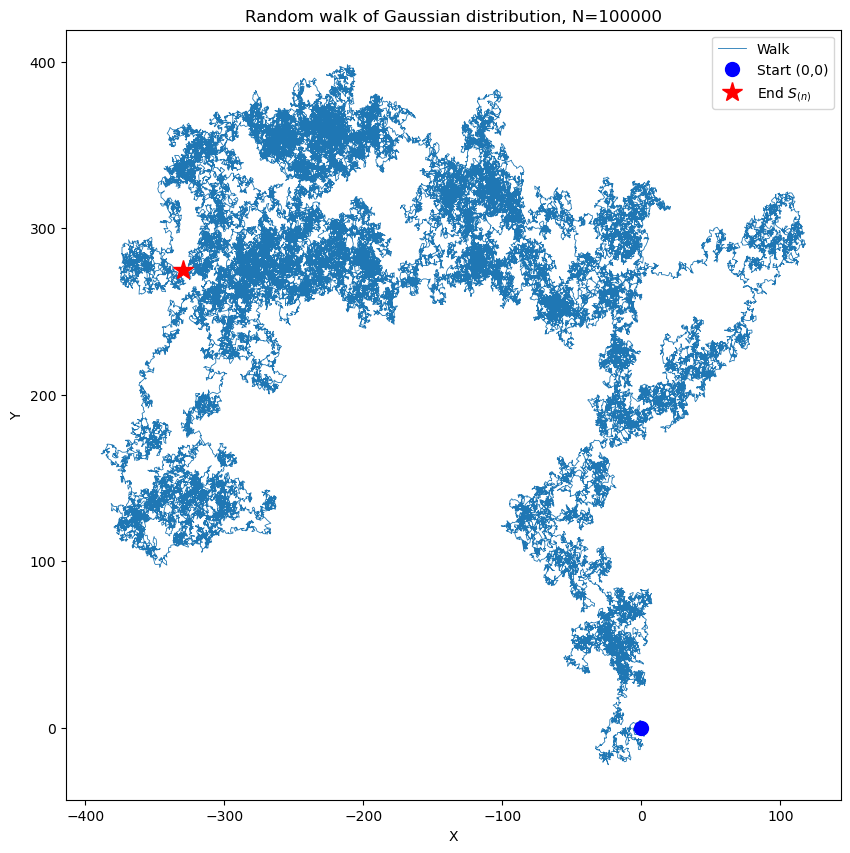

In [14]:
plt.figure(figsize=(10, 10))
plt.plot(path[:, 0], path[:, 1],  linewidth=0.6, label='Walk')
plt.plot(0, 0, 'bo', markersize=10, label='Start (0,0)')
plt.plot(path[-1, 0], path[-1, 1], 'r*', markersize=15, label='End $S_{(n)}$')

plt.title(f"Random walk of Gaussian distribution, N={N}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

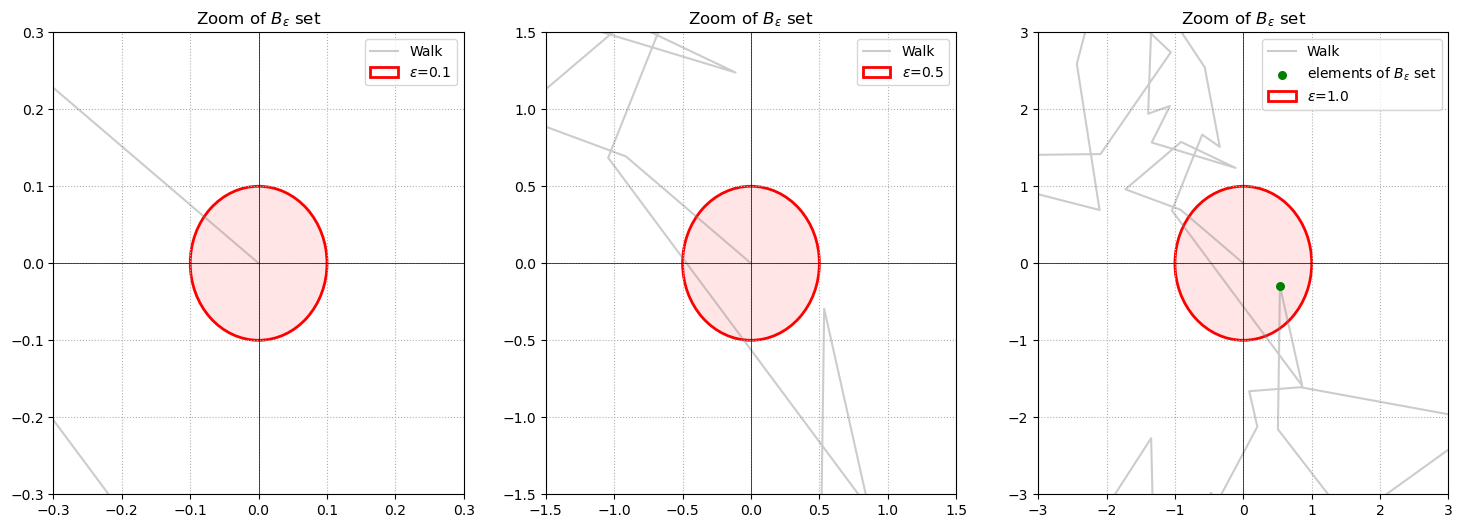

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, epsilon in enumerate(epsilons):
    ax = axes[i]
    
    distances_plot = np.linalg.norm(path[1:], axis=1)
    mask = distances_plot <= epsilon
    returned_points = path[1:][mask]

    ax.plot(path[:2000, 0], path[:2000, 1], color='gray', alpha=0.4, label='Walk')

    if len(returned_points) > 0:
        ax.scatter(returned_points[:, 0], returned_points[:, 1],
                    color='green', s=30, zorder=5, label='elements of $B_{{\epsilon}}$ set')


    circle_zoom = plt.Circle((0, 0), epsilon, color='red', fill=True, alpha=0.1)
    circle_edge = plt.Circle((0, 0), epsilon, color='red', fill=False, linewidth=2, label=f'$\epsilon$={epsilon}')
    ax.add_patch(circle_zoom)
    ax.add_patch(circle_edge)

    margin = epsilon * 3
    ax.set_xlim(-margin, margin)
    ax.set_ylim(-margin, margin)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_title(f"Zoom of $B_{{\epsilon}}$ set")
    ax.legend()
    ax.grid(True, linestyle=':')
plt.show()

* ### Distribution of return times using histogram and ECDF

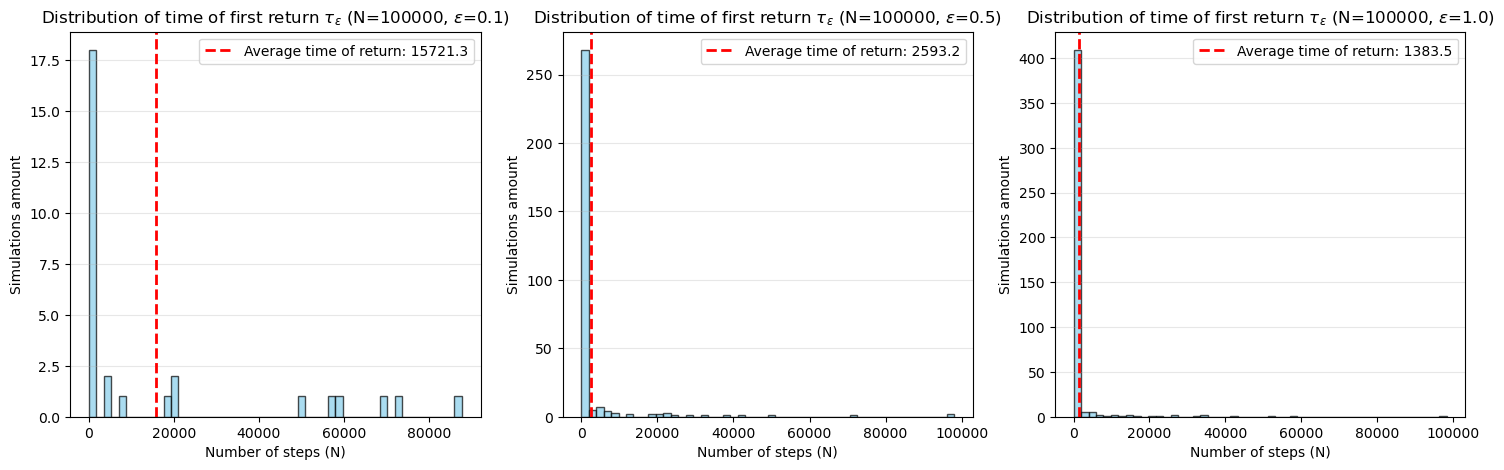

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, epsilon in enumerate(epsilons):
    ax = axes[i]
    
    current_times = all_stats.get(epsilon, []) if return_times else 0
    
    if len(current_times) > 0:
        ax.hist(current_times, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

        avg_tau = np.mean(current_times)
        ax.axvline(avg_tau, color='red', linestyle='dashed', linewidth=2,
                    label=f'Average time of return: {avg_tau:.1f}')
    else:
        0

    ax.set_title(f"Distribution of time of first return $\\tau_{{\epsilon}}$ (N={N}, $\epsilon$={epsilon})")
    ax.set_xlabel("Number of steps (N)")
    ax.set_ylabel("Simulations amount")
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
plt.show()

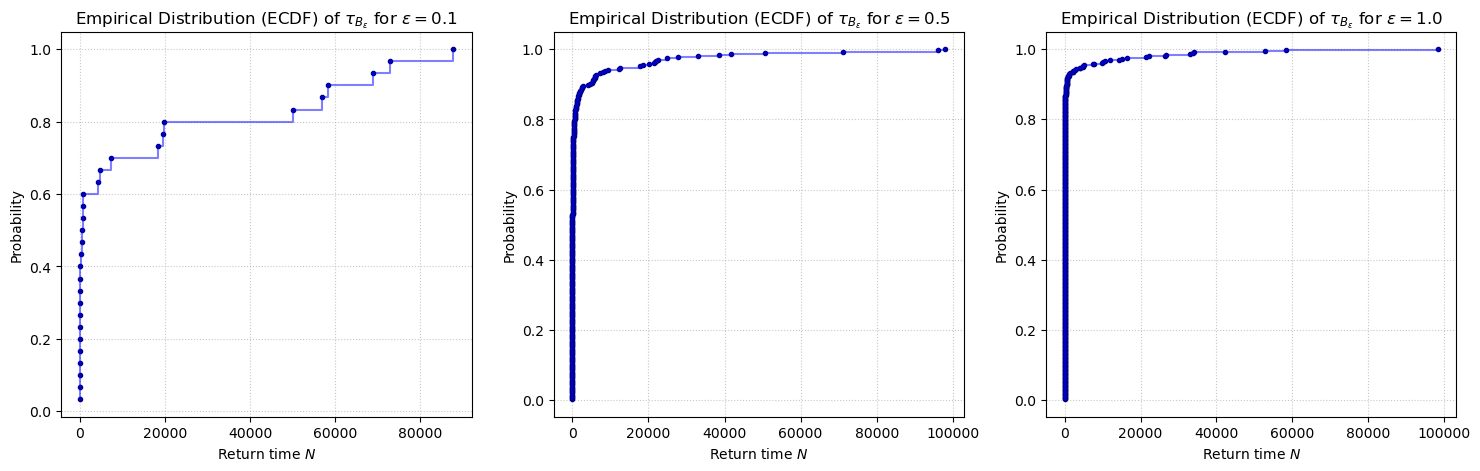

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, epsilon in enumerate(epsilons):
    ax = axes[i]
    
    current_times = all_stats.get(epsilon, [])
    
    sorted_times = np.sort(current_times)
    y_values = np.arange(1, len(sorted_times) + 1) / len(sorted_times)

    ax.plot(sorted_times, y_values, marker='.', linestyle='none', color='darkblue', label='ECDF')
    ax.step(sorted_times, y_values, where='post', color='blue', alpha=0.5)

    ax.set_title(rf"Empirical Distribution (ECDF) of $\tau_{{B_{{\epsilon}}}}$ for $\epsilon={epsilon}$")
    ax.set_xlabel("Return time $N$")
    ax.set_ylabel("Probability")
    ax.grid(True, linestyle=':', alpha=0.7)
plt.show()

* ### Uniform Distribution

In [18]:
all_stats = {}
for epsilon in epsilons:
    print("_" * 50)
    print(f"*** Simulation start (N={N}, Epsilon={epsilon}) ***")
    return_times = []
    returns_count = 0
    failed_simulations = 0
    successful_iterations = []
    results_table = []
    for i in range(reps):
        path, tau = simulation(N, epsilon, dist_type='Uniform')

        if tau is not None:
            returns_count += 1
            return_times.append(tau)
            successful_iterations.append(i + 1)
        else:
            failed_simulations += 1
    for i in range(len(successful_iterations)):
        results_table.append([successful_iterations[i], return_times[i]])

    print(f"Simulations without return: {failed_simulations}")
    prob_return = returns_count / reps
    avg_return_time = np.mean(return_times) if return_times else 0
    print("_" * 30)
    print(f"Estimated probability of return: {prob_return:.2f}")
    print(f"Estimated conditional expected return time: {avg_return_time:.2f}")
    print("=" * 40)
    all_stats[epsilon] = return_times

__________________________________________________
*** Simulation start (N=100000, Epsilon=0.1) ***
Simulations without return: 434
______________________________
Estimated probability of return: 0.13
Estimated conditional expected return time: 9791.38
__________________________________________________
*** Simulation start (N=100000, Epsilon=0.5) ***
Simulations without return: 85
______________________________
Estimated probability of return: 0.83
Estimated conditional expected return time: 1519.65
__________________________________________________
*** Simulation start (N=100000, Epsilon=1.0) ***
Simulations without return: 10
______________________________
Estimated probability of return: 0.98
Estimated conditional expected return time: 268.30


* ### Plot of Uniform distribution simulation

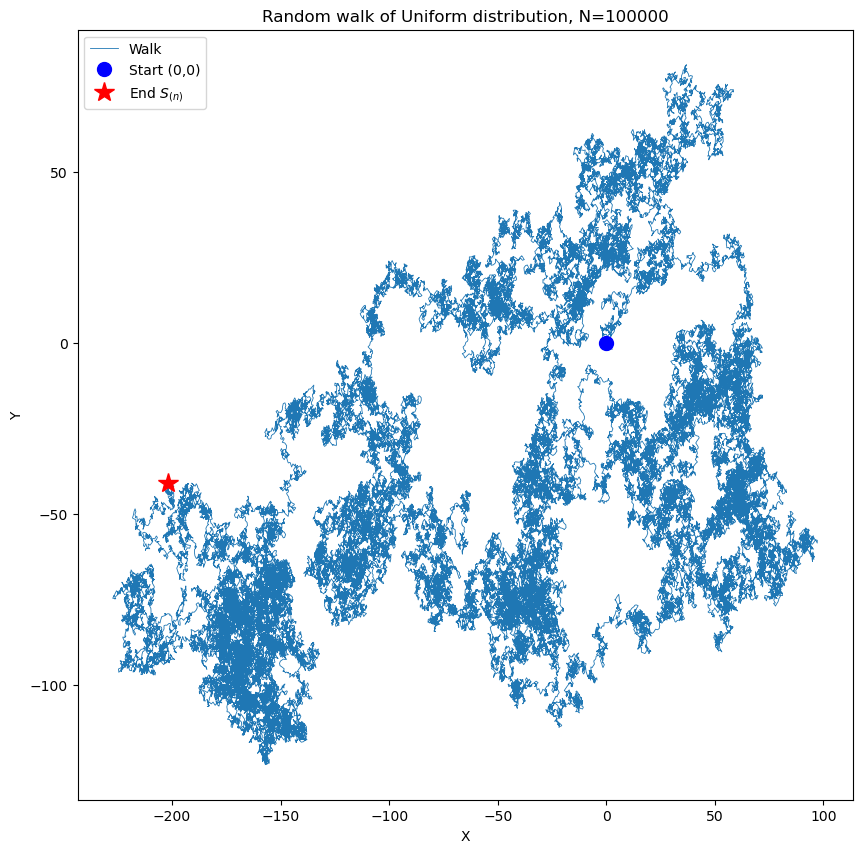

In [19]:
plt.figure(figsize=(10, 10))
plt.plot(path[:, 0], path[:, 1],  linewidth=0.6, label='Walk')
plt.plot(0, 0, 'bo', markersize=10, label='Start (0,0)')
plt.plot(path[-1, 0], path[-1, 1], 'r*', markersize=15, label='End $S_{(n)}$')

plt.title(f"Random walk of Uniform distribution, N={N}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

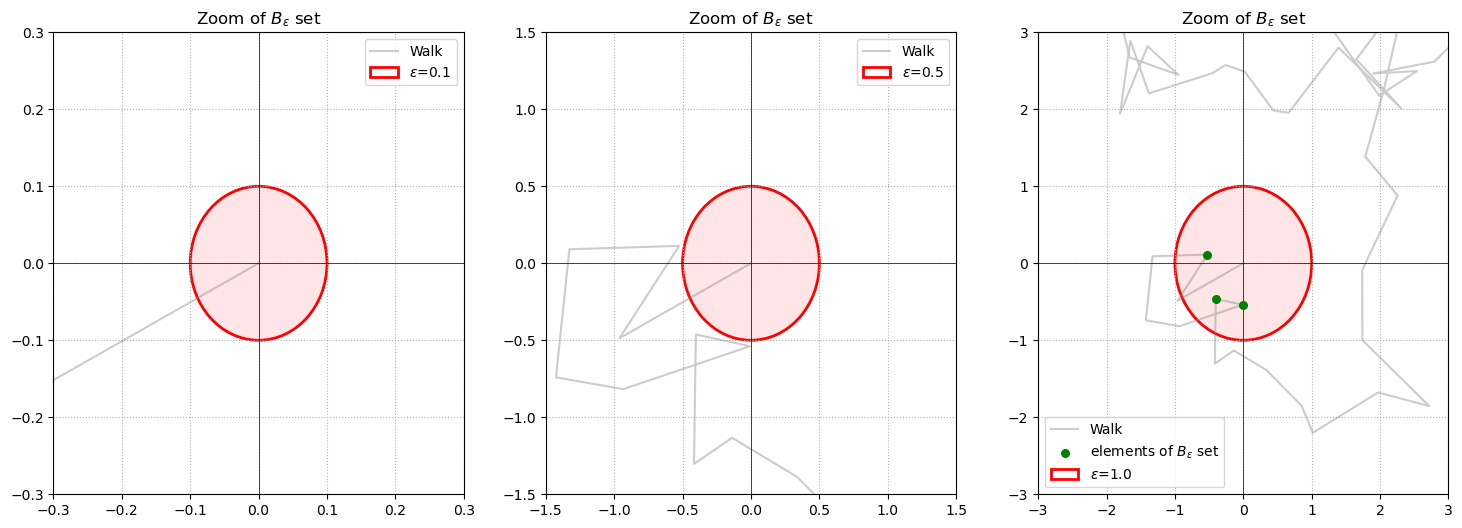

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, epsilon in enumerate(epsilons):
    ax = axes[i]
    
    distances_plot = np.linalg.norm(path[1:], axis=1)
    mask = distances_plot <= epsilon
    returned_points = path[1:][mask]

    ax.plot(path[:2000, 0], path[:2000, 1], color='gray', alpha=0.4, label='Walk')

    if len(returned_points) > 0:
        ax.scatter(returned_points[:, 0], returned_points[:, 1],
                    color='green', s=30, zorder=5, label='elements of $B_{{\epsilon}}$ set')


    circle_zoom = plt.Circle((0, 0), epsilon, color='red', fill=True, alpha=0.1)
    circle_edge = plt.Circle((0, 0), epsilon, color='red', fill=False, linewidth=2, label=f'$\epsilon$={epsilon}')
    ax.add_patch(circle_zoom)
    ax.add_patch(circle_edge)

    margin = epsilon * 3
    ax.set_xlim(-margin, margin)
    ax.set_ylim(-margin, margin)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_title(f"Zoom of $B_{{\epsilon}}$ set")
    ax.legend()
    ax.grid(True, linestyle=':')
plt.show()

* ### Distribution of return times using histogram and ECDF

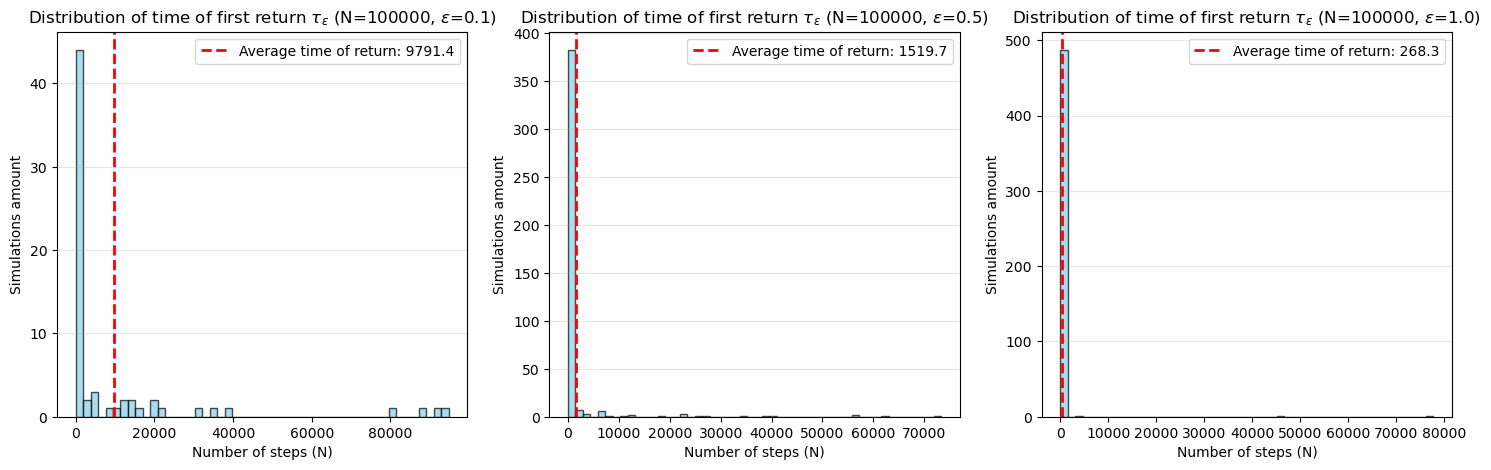

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, epsilon in enumerate(epsilons):
    ax = axes[i]
    
    current_times = all_stats.get(epsilon, []) if return_times else 0
    
    if len(current_times) > 0:
        ax.hist(current_times, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

        avg_tau = np.mean(current_times)
        ax.axvline(avg_tau, color='red', linestyle='dashed', linewidth=2,
                    label=f'Average time of return: {avg_tau:.1f}')
    else:
        0

    ax.set_title(f"Distribution of time of first return $\\tau_{{\epsilon}}$ (N={N}, $\epsilon$={epsilon})")
    ax.set_xlabel("Number of steps (N)")
    ax.set_ylabel("Simulations amount")
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
plt.show()

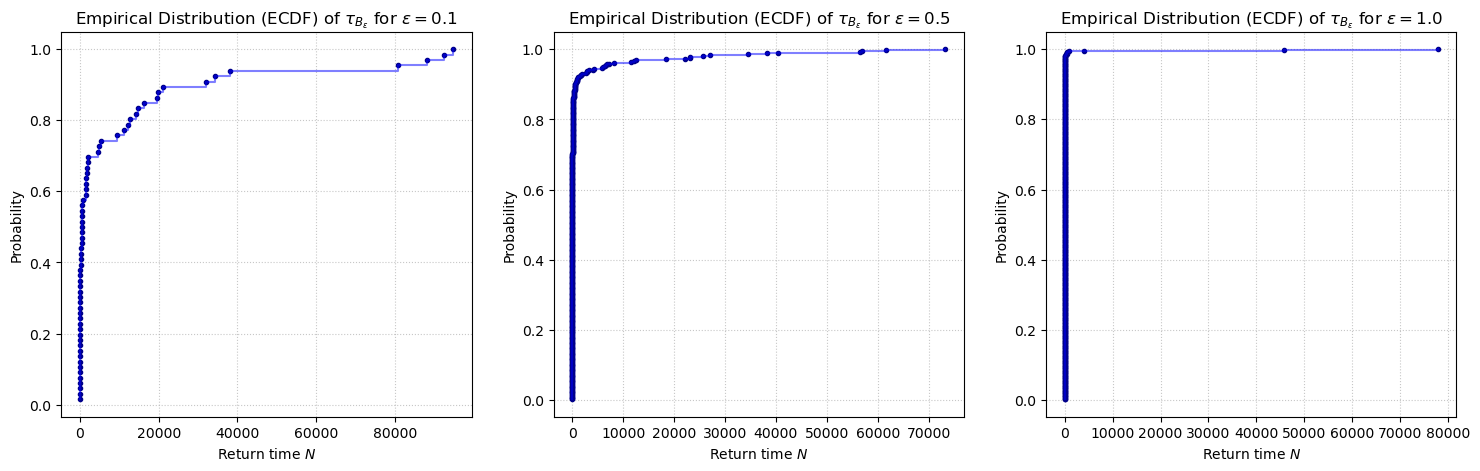

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, epsilon in enumerate(epsilons):
    ax = axes[i]
    
    current_times = all_stats.get(epsilon, [])
    
    sorted_times = np.sort(current_times)
    y_values = np.arange(1, len(sorted_times) + 1) / len(sorted_times)

    ax.plot(sorted_times, y_values, marker='.', linestyle='none', color='darkblue', label='ECDF')
    ax.step(sorted_times, y_values, where='post', color='blue', alpha=0.5)

    ax.set_title(rf"Empirical Distribution (ECDF) of $\tau_{{B_{{\epsilon}}}}$ for $\epsilon={epsilon}$")
    ax.set_xlabel("Return time $N$")
    ax.set_ylabel("Probability")
    ax.grid(True, linestyle=':', alpha=0.7)
plt.show()

* ### Cauchy distribution

In [23]:
all_stats = {}
for epsilon in epsilons:
    print("_" * 50)
    print(f"*** Simulation start (N={N}, Epsilon={epsilon}) ***")
    return_times = []
    returns_count = 0
    failed_simulations = 0
    successful_iterations = []
    results_table = []
    for i in range(reps):
        path, tau = simulation(N, epsilon, dist_type='Cauchy')

        if tau is not None:
            returns_count += 1
            return_times.append(tau)
            successful_iterations.append(i + 1)
        else:
            failed_simulations += 1
    for i in range(len(successful_iterations)):
        results_table.append([successful_iterations[i], return_times[i]])

    print(f"Simulations without return: {failed_simulations}")
    prob_return = returns_count / reps
    avg_return_time = np.mean(return_times) if return_times else 0
    print("_" * 30)
    print(f"Estimated probability of return: {prob_return:.2f}")
    print(f"Estimated conditional expected return time: {avg_return_time:.2f}")
    print("=" * 40)
    all_stats[epsilon] = return_times

__________________________________________________
*** Simulation start (N=100000, Epsilon=0.1) ***
Simulations without return: 498
______________________________
Estimated probability of return: 0.00
Estimated conditional expected return time: 3.00
__________________________________________________
*** Simulation start (N=100000, Epsilon=0.5) ***
Simulations without return: 447
______________________________
Estimated probability of return: 0.11
Estimated conditional expected return time: 3.23
__________________________________________________
*** Simulation start (N=100000, Epsilon=1.0) ***
Simulations without return: 367
______________________________
Estimated probability of return: 0.27
Estimated conditional expected return time: 4.83


* ### Plot of Cauchy distribution simulation

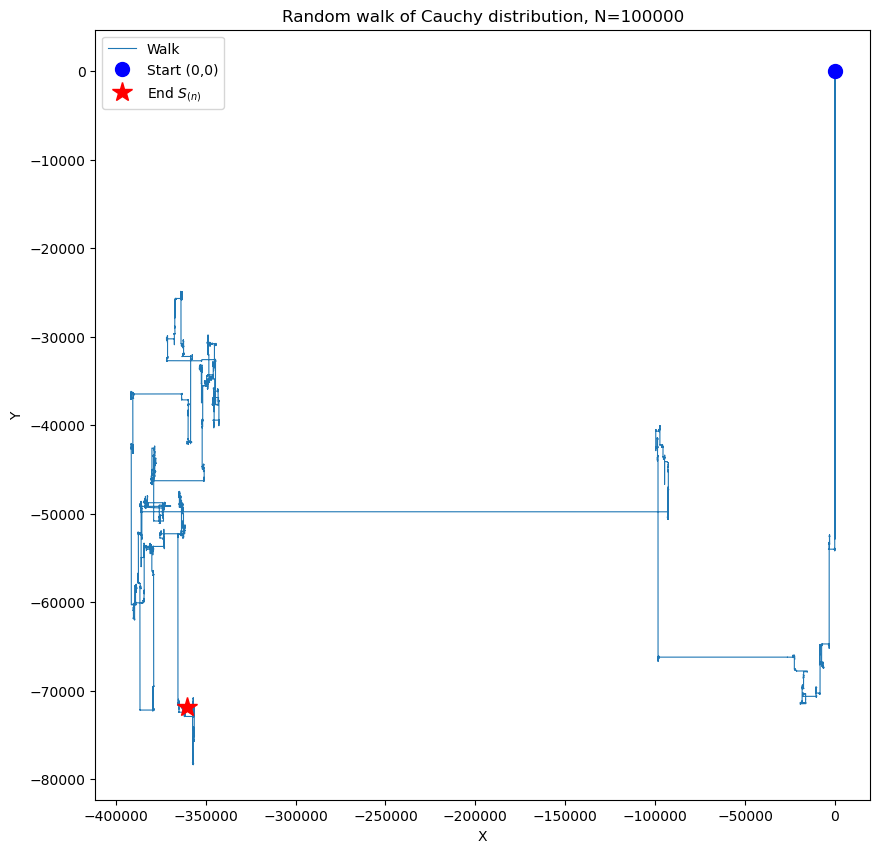

In [24]:
plt.figure(figsize=(10, 10))
plt.plot(path[:, 0], path[:, 1],  linewidth=0.8, label='Walk')
plt.plot(0, 0, 'bo', markersize=10, label='Start (0,0)')
plt.plot(path[-1, 0], path[-1, 1], 'r*', markersize=15, label='End $S_{(n)}$')

plt.title(f"Random walk of Cauchy distribution, N={N}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

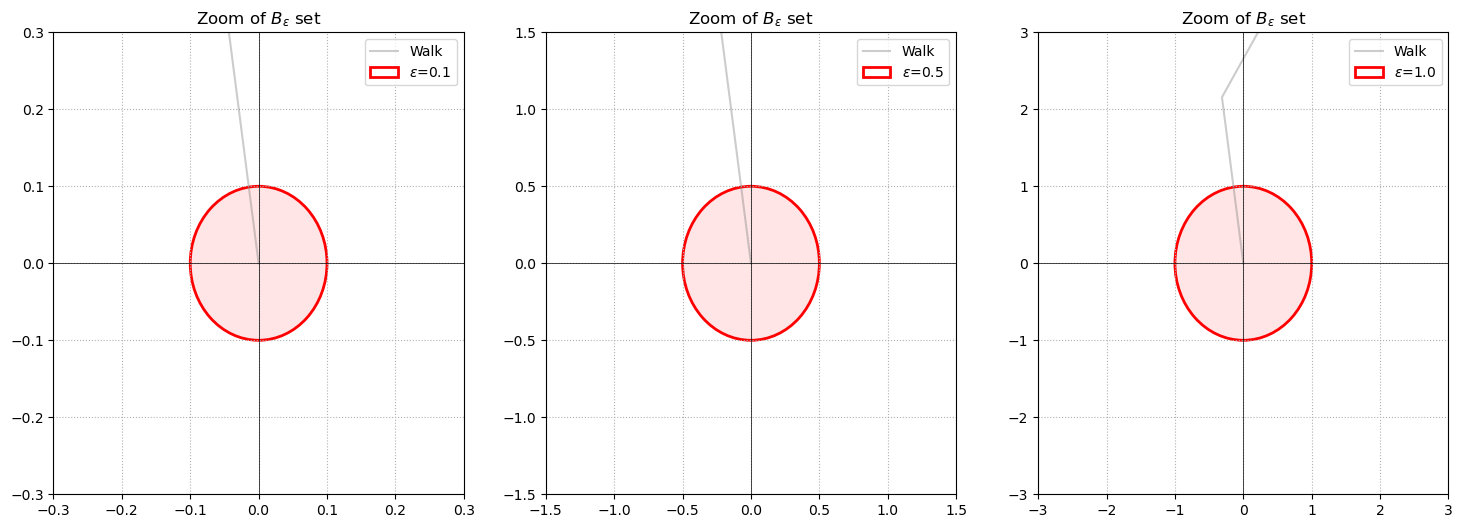

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, epsilon in enumerate(epsilons):
    ax = axes[i]
    
    distances_plot = np.linalg.norm(path[1:], axis=1)
    mask = distances_plot <= epsilon
    returned_points = path[1:][mask]

    ax.plot(path[:2000, 0], path[:2000, 1], color='gray', alpha=0.4, label='Walk')

    if len(returned_points) > 0:
        ax.scatter(returned_points[:, 0], returned_points[:, 1],
                    color='green', s=30, zorder=5, label='elements of $B_{{\epsilon}}$ set')


    circle_zoom = plt.Circle((0, 0), epsilon, color='red', fill=True, alpha=0.1)
    circle_edge = plt.Circle((0, 0), epsilon, color='red', fill=False, linewidth=2, label=f'$\epsilon$={epsilon}')
    ax.add_patch(circle_zoom)
    ax.add_patch(circle_edge)

    margin = epsilon * 3
    ax.set_xlim(-margin, margin)
    ax.set_ylim(-margin, margin)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_title(f"Zoom of $B_{{\epsilon}}$ set")
    ax.legend()
    ax.grid(True, linestyle=':')
plt.show()

* ### Distribution of return times using histogram and ECDF

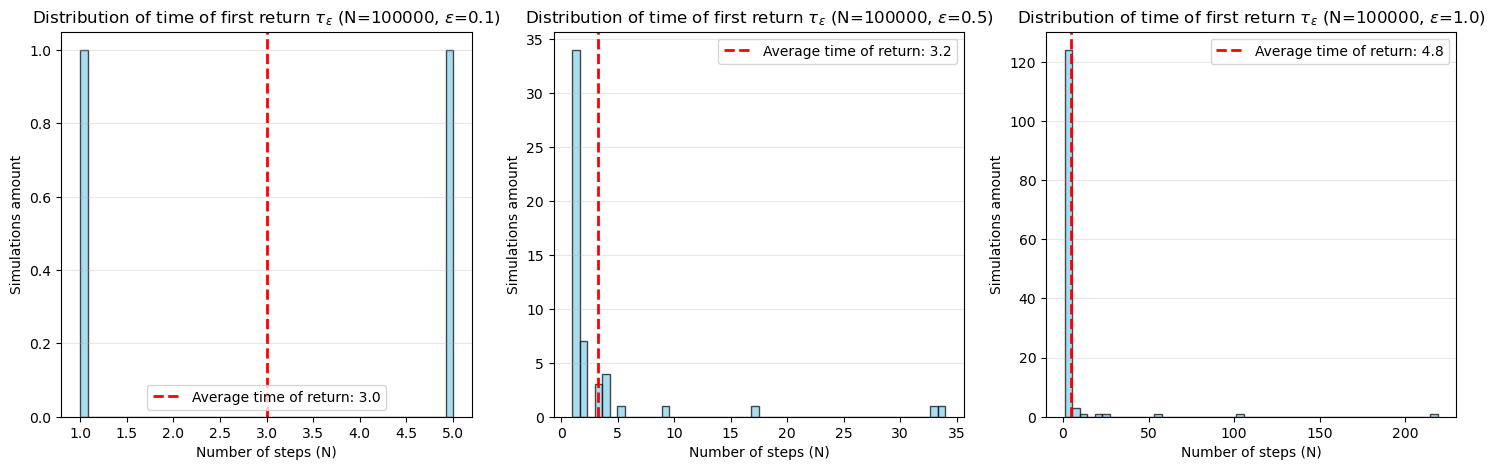

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, epsilon in enumerate(epsilons):
    ax = axes[i]
    
    current_times = all_stats.get(epsilon, []) if return_times else 0
    
    if len(current_times) > 0:
        ax.hist(current_times, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

        avg_tau = np.mean(current_times)
        ax.axvline(avg_tau, color='red', linestyle='dashed', linewidth=2,
                    label=f'Average time of return: {avg_tau:.1f}')
        ax.legend()
    else:
        0

    ax.set_title(f"Distribution of time of first return $\\tau_{{\epsilon}}$ (N={N}, $\epsilon$={epsilon})")
    ax.set_xlabel("Number of steps (N)")
    ax.set_ylabel("Simulations amount")
    ax.grid(axis='y', alpha=0.3)
plt.show()

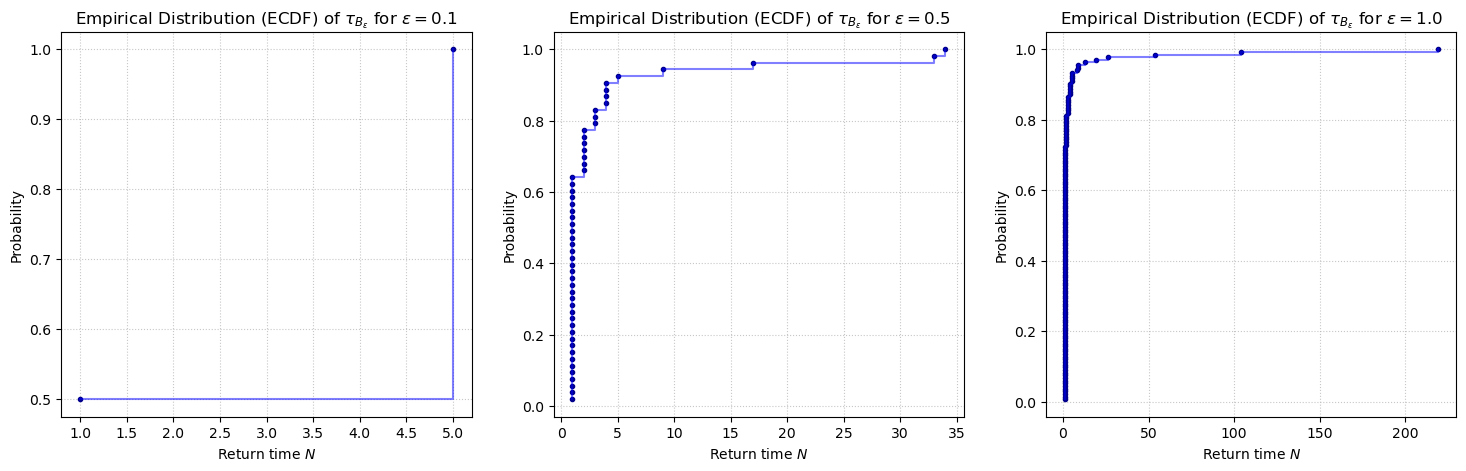

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, epsilon in enumerate(epsilons):
    ax = axes[i]
    
    current_times = all_stats.get(epsilon, [])
    
    sorted_times = np.sort(current_times)
    y_values = np.arange(1, len(sorted_times) + 1) / len(sorted_times)

    ax.plot(sorted_times, y_values, marker='.', linestyle='none', color='darkblue', label='ECDF')
    ax.step(sorted_times, y_values, where='post', color='blue', alpha=0.5)

    ax.set_title(rf"Empirical Distribution (ECDF) of $\tau_{{B_{{\epsilon}}}}$ for $\epsilon={epsilon}$")
    ax.set_xlabel("Return time $N$")
    ax.set_ylabel("Probability")
    ax.grid(True, linestyle=':', alpha=0.7)
plt.show()

<h2>Part 3: Interpratation & Discussion</h2>

* ### 1. The Effect of $\epsilon$ (Neighborhood Size)
The simulation results clearly demonstrate that the probability of return, $\hat{P}(\tau_{\epsilon} < N)$, is strictly increasing with respect to the neighborhood radius $\epsilon$.

* **Observation:** For the Gaussian random walk, the estimated probability of return increased from approximately **0.07** at $\epsilon=0.1$ to **0.87** at $\epsilon=1.0$.
* **Interpretation:** This aligns with geometric intuition. A larger $\epsilon$ defines a larger target area $B_{\epsilon}$ for the random walk to hit. As $\epsilon \to 0$, the probability of hitting the exact point $(0,0)$ in a continuous space is zero. However, for any fixed $\epsilon > 0$, theory suggests recurrence (probability $\to 1$ as $N \to \infty$). Our simulation shows that for small $\epsilon$ (0.1), a size of random walk, which is $N=10^5$ is often insufficient to observe these returns, resulting in a low empirical probability.

* ### 2. Gaussian vs. Uniform vs. Heavy-tailed Increments
The behavior of the random walk is heavily influenced by the distribution of the increments $X_k$.

* **Gaussian and Uniform Distributions:**
    Both distributions have simmilar diffusive(pl. "rozproszony") behavior. However, the Uniform random walk (steps in $[-1, 1]$) showed slightly higher return probabilities (e.g., $0.98$ for $\epsilon=1.0$) compared to the Gaussian walk ($0.87$).
    * *Reasoning:* This is likely due to the variance differences. The variance of $U(-1,1)$ is $1/3$, while the standard Gaussian variance is $1$. The Uniform walker moves "slower" (has a lower diffusion coefficient), keeping it closer to the origin for longer periods within the finite time $N$, therefore increasing the chance of hitting $B_{\epsilon}$.

* **Cauchy Distribution (Heavy-tailed):**
    The Cauchy walk behaved drastically differently. Even for the largest neighborhood ($\epsilon=1.0$), the return probability was only **0.32**, and for $\epsilon=0.1$, it was **0.00** (no returns observed).
    * *Reasoning:* The Cauchy distribution lacks a finite variance and mean. It is characterized by occasional massive jumps (Lévy flights). Once a large jump occurs, the walker is transported far from the origin. The "local" steps required to return to $B_{\epsilon}$ are overwhelmed by these large excursions, making a return within $N=10^5$ steps highly unlikely.

* ### 3. Recurrence in Practice
Theoretically, a random walk in $\mathbb{R}^2$ with finite variance (like Gaussian or Uniform) is **neighborhood recurrent**, meaning it should return to $B_{\epsilon}$ with probability 1 as $N \to \infty$.

* **In Practice:** We observed probabilities less than 1 (e.g., $0.61$ for Gaussian, $\epsilon=0.5$).
* **Conclusion:** This indicates that while the walk is theoretically recurrent, the **time required to return** can be exceedingly long. The "failed" simulations are not proofs of failure, but rather evidence that the return time $\tau_{\epsilon}$ often exceeds our simulation size of $N=100,000$.

* ### 4. Tail Heaviness and Conditional Expected Return Time
A counter-intuitive result was observed regarding the **Conditional Expected Return Time** ($\hat{E}[\tau_{\epsilon} | \tau_{\epsilon} < N]$).

* **Gaussian:** The average return time was high (e.g., $\approx 3266$ steps for $\epsilon=0.1$). This reflects the diffusive nature where the particle wanders locally but takes time to cross the specific boundary.
* **Cauchy:** Surprisingly, the conditional average return time was extremely low (e.g., $\approx 3.5$ to $4.5$ steps).
* **Interpretation:** This is a result of **selection bias**. The Cauchy walk generally moves away very quickly due to heavy tails. The *only* realizations that successfully return to $B_{\epsilon}$ are those that do so almost immediately (in the first few steps) *before* a large jump occurs. If the Cauchy walker does not return instantly, it is propelled so far away that it does not return within the simulation limits. Thus, we only capture the "immediate" returns in our average, skewing the metric downward.

* ### 5. Limitations of Finite-Time Simulations
The primary limitation of this study is the finite size of random walk of $N=100,000$.
* **Truncation Error:** We cannot distinguish between a walker that will *never* return (transience) and one that would return at step $N+1$.
* **Infinite Expectation:** For recurrent random walks in 2D, the theoretical expected return time is infinite ($E[\tau] = \infty$). In our simulation, we calculate a finite sample mean, but this value would likely continue to grow if we increased $N$.